# Embedding & Generator Model Goldilocks: A Fresh Search

Every notebook in this series so far (`11`-`16`) held two things constant that were
flagged as caveats every single time: the embedding model (`openai/text-embedding-3-small`)
and the generator model (`meta-llama/llama-3.1-8b-instruct`). `16`'s held-out validation
confirmed the compounded pipeline built on top of those two constants generalizes -- but it
never asked whether *either constant itself* is the right choice. This notebook does.

Two phases, each isolating one model choice, built on the validated `11`+`12`+`13`+`14`+`15`
stack (sentence + metadata chunks @ 64t, hybrid BM25+dense retrieval @ alpha=0.3 driven by
HyDE doc+query, Cohere Rerank 4-Pro over a candidate pool of 20, final 2 chunks, no
repacking) exactly as `16` validated it:

1. **Embedding model comparison** -- the paper's own §3.2 flags embedding choice as
   material to retrieval quality (Table 5 compares 14 candidates), but this repo never
   tested a single alternative. Every candidate here is actually available as an OpenRouter
   embedding model (verified against the live catalog before writing this notebook, after an
   earlier wrong assumption that OpenRouter only proxies OpenAI's own embedding models).
2. **Generator model comparison** -- `07`'s stale fine-tuning notebook aside, no notebook in
   this repo has ever swapped the generation model itself. This doesn't require GPU access
   or training (unlike `07`'s LoRA approach) -- it's a pure inference-time model swap, same
   mechanism the judge/generator split already uses.

Both phases report **average per-question wall-clock latency alongside composite score** --
a model that wins on quality but adds meaningful latency is a real tradeoff, not a free win,
and the composite score alone doesn't capture that.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever, OpenRouterReranker
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

Same fixed-sample mechanism as `11`-`16` -- `EVAL_SAMPLE_SIZE` questions chosen once, up
front, and reused for every config in every phase below.

In [3]:
DATASET_NAME = "delucionqa"
EVAL_SAMPLE_SIZE = 20

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 90 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Fixed Judge Model

In [4]:
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Judge model configured (held constant across every phase -- not this notebook's variable)")


✓ Judge model configured (held constant across every phase -- not this notebook's variable)


## Step 5: Chunking Foundation (text only -- embedding-independent)

Chunk *text* doesn't depend on embedding model, so this is built once and reused across
every embedding candidate in Phase 1 -- only the vector representations differ per
candidate, not the chunks themselves.

In [5]:
CHUNK_TARGET_TOKENS = 64
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.3
CANDIDATE_K = 20
FINAL_K = 2


def sentence_level_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = []
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        if not sentences:
            continue
        sent_tokens = [count_tokens(s) for s in sentences]
        n = len(sentences)
        i, chunk_idx = 0, 0
        while i < n:
            chunk_sents, chunk_tok_count, j = [], 0, i
            while j < n and (not chunk_sents or chunk_tok_count + sent_tokens[j] <= target_tokens):
                chunk_sents.append(sentences[j])
                chunk_tok_count += sent_tokens[j]
                j += 1
            chunk_text = " ".join(chunk_sents)
            documents.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_sent{chunk_idx}",
                    "row_id": doc["row_id"],
                    "tokens": count_tokens(chunk_text),
                },
            ))
            chunk_idx += 1
            overlap_count = int(len(chunk_sents) * overlap_fraction)
            step = max(len(chunk_sents) - overlap_count, 1)
            i += step
    return documents


def metadata_enhanced_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = sentence_level_chunks(docs_df, target_tokens=target_tokens, overlap_fraction=overlap_fraction)

    doc_id_to_heading = {}
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        heading = sentences[0] if sentences else doc["text"][:80]
        doc_id_to_heading[doc["doc_id"]] = " ".join(heading.split()[:12])

    enhanced = []
    for d in documents:
        source_doc_id = d.metadata["chunk_id"].rsplit("_sent", 1)[0]
        heading = doc_id_to_heading.get(source_doc_id, "")
        new_text = f"[Context: {heading}]\n{d.page_content}"
        enhanced.append(Document(
            page_content=new_text,
            metadata={**d.metadata, "tokens": count_tokens(new_text)},
        ))
    return enhanced


def apply_hyde(query, llm, n_docs=1, concat_with_query=True):
    """Winning HyDE config from 13: 1 hypothetical doc, concatenated with the query,
    used to drive retrieval only. The HyDE-generation model itself is held fixed at
    this notebook's default across both phases -- it's a retrieval-transformation
    concern (13's own variable), not this notebook's embedding/generator axis."""
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


print("Building chunking foundation (sentence + metadata, 64t, 10% overlap)...")
documents = metadata_enhanced_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
reranker = OpenRouterReranker("cohere/rerank-4-pro", openrouter_token)
print("✓ HyDE query-transform model and Cohere 4-Pro reranker ready (both held fixed)")


Building chunking foundation (sentence + metadata, 64t, 10% overlap)...
✓ Built 456 chunks, avg 68 tokens/chunk
✓ HyDE query-transform model and Cohere 4-Pro reranker ready (both held fixed)


## Step 6: Evaluation Runner

Every config runs the fixed 20-question set through: HyDE-transform the query (fixed model)
-> retrieve `CANDIDATE_K` hybrid-ranked candidates (embedding model varies in Phase 1) ->
Cohere 4-Pro rerank to `FINAL_K` -> generate from the original question (generator model
varies in Phase 2) -> retry judge annotation up to 3x -> compute TRACe metrics + the same
composite score `11`-`16` used, plus **average per-question wall-clock latency** for the
retrieval+generation portion (excludes judge annotation, which is a fixed evaluation cost
common to every config, not part of what a production system would pay per query).

In [6]:
def evaluate_config(config_name, retriever, generator_llm, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | generator_llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    latencies = []
    for _, row in eval_questions_df.iterrows():
        original_question = row["question"]
        try:
            t0 = time.time()
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=1, concat_with_query=True)
            candidates = retriever.retrieve(retrieval_query)[:CANDIDATE_K]
            reranked_docs = reranker.rerank(original_question, candidates, top_k=FINAL_K)
            retrieved_texts = [d.page_content for d in reranked_docs]

            response_text = rag_chain.invoke({"context": format_docs(reranked_docs), "question": original_question})
            latencies.append(time.time() - t0)

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "avg_latency_sec": round(float(np.mean(latencies)), 2) if latencies else None,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_config defined")


✓ evaluate_config defined


## Step 7: Phase 1 -- Embedding Model Comparison

Every candidate rebuilds the hybrid retriever's vector store fresh (BM25's side is
text-only and unaffected) with the current default generator model held fixed. Candidates:
the current default (`openai/text-embedding-3-small`) plus four alternatives actually
available on OpenRouter's embedding catalog.

In [7]:
DEFAULT_GENERATOR_MODEL = "meta-llama/llama-3.1-8b-instruct"

EMBEDDING_CANDIDATES = [
    "openai/text-embedding-3-small",   # current default / baseline
    "google/gemini-embedding-001",
    "qwen/qwen3-embedding-8b",
    "baai/bge-m3"
]

print("=" * 100)
print(f"PHASE 1: EMBEDDING MODEL COMPARISON (generator fixed @ {DEFAULT_GENERATOR_MODEL}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

default_generator_llm = get_generation_llm(openrouter_token, model=DEFAULT_GENERATOR_MODEL)

phase1_results = []
for model_name in EMBEDDING_CANDIDATES:
    print(f"\n--- {model_name} ---")
    try:
        embedding_model = get_embedding_model(openrouter_token, model=model_name)
        config_slug = model_name.replace("/", "_").replace(".", "_").lower()
        retriever = HybridRetriever(documents, embedding_model, k=CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                     dataset_name=DATASET_NAME, config_name=f"emb_{config_slug}")
        result = evaluate_config(f"p1_{model_name}", retriever, default_generator_llm, eval_questions_df)
        phase1_results.append(result)
        if result["composite"] is not None:
            print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
                  f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
                  f"Composite={result['composite']:.4f} Latency={result['avg_latency_sec']:.2f}s "
                  f"(failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
        else:
            print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    except Exception as e:
        print(f"  ✗ Embedding model unavailable or errored: {str(e)[:80]}")
        phase1_results.append({"config": f"p1_{model_name}", "n_eval": 0, "n_failed": EVAL_SAMPLE_SIZE,
                                "avg_latency_sec": None, "context_relevance": None, "utilization": None,
                                "completeness": None, "adherence": None, "composite": None})

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: EMBEDDING MODEL COMPARISON (generator fixed @ meta-llama/llama-3.1-8b-instruct), 20 fixed questions

--- openai/text-embedding-3-small ---
  CR=0.5685 Util=0.3842 Comp=0.6712 Adh=0.9500 Composite=0.6898 Latency=12.39s (failed 0/20)

--- google/gemini-embedding-001 ---
  CR=0.6322 Util=0.4025 Comp=0.6845 Adh=0.9000 Composite=0.6993 Latency=9.73s (failed 0/20)

--- qwen/qwen3-embedding-8b ---
  CR=0.6183 Util=0.4108 Comp=0.7000 Adh=0.9000 Composite=0.6980 Latency=12.39s (failed 0/20)

--- baai/bge-m3 ---
  CR=0.6051 Util=0.3886 Comp=0.7141 Adh=1.0000 Composite=0.7272 Latency=10.74s (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,n_eval,n_failed,avg_latency_sec,context_relevance,utilization,completeness,adherence,composite
3,p1_baai/bge-m3,20,0,10.74,0.605140,0.388615,0.714050,1.00,0.727199
1,p1_google/gemini-embedding-001,20,0,9.73,0.632220,0.402500,0.684525,0.90,0.699331
2,p1_qwen/qwen3-embedding-8b,20,0,12.39,0.618330,0.410835,0.700000,0.90,0.698041
0,p1_openai/text-embedding-3-small,20,0,12.39,0.568475,0.384175,0.671190,0.95,0.689771


## Step 8: Phase 2 -- Generator Model Comparison

Takes Phase 1's winning embedding model (rebuilding the retriever once with it) and
compares generator models, holding retrieval/rerank fixed. Candidates: the current default
(`meta-llama/llama-3.1-8b-instruct`) plus three alternatives spanning different model
families and sizes.

In [8]:
phase1_winner_row = phase1_df.dropna(subset=["composite"]).iloc[0]
phase1_winner_model = phase1_winner_row["config"].replace("p1_", "")
print(f"Phase 1 winner: {phase1_winner_model} -- rebuilding retriever with it, then sweeping generator model\n")

winning_embedding_model = get_embedding_model(openrouter_token, model=phase1_winner_model)
winning_slug = phase1_winner_model.replace("/", "_").replace(".", "_").lower()
winning_retriever = HybridRetriever(documents, winning_embedding_model, k=CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                     dataset_name=DATASET_NAME, config_name=f"emb_winner_{winning_slug}")
print(f"✓ Retriever rebuilt with winning embedding model ({phase1_winner_model})\n")

GENERATOR_CANDIDATES = [
    DEFAULT_GENERATOR_MODEL,          # current default / baseline
    "microsoft/phi-4",
    "google/gemma-3-27b-it",
    "mistralai/voxtral-small-24b-2507",
]

print("=" * 100)
print(f"PHASE 2: GENERATOR MODEL COMPARISON (embedding fixed @ {phase1_winner_model}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for model_name in GENERATOR_CANDIDATES:
    print(f"\n--- {model_name} ---")
    try:
        generator_llm = get_generation_llm(openrouter_token, model=model_name)
        result = evaluate_config(f"p2_{model_name}", winning_retriever, generator_llm, eval_questions_df)
        phase2_results.append(result)
        if result["composite"] is not None:
            print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
                  f"Composite={result['composite']:.4f} Latency={result['avg_latency_sec']:.2f}s "
                  f"(failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
        else:
            print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    except Exception as e:
        print(f"  ✗ Generator model unavailable or errored: {str(e)[:80]}")
        phase2_results.append({"config": f"p2_{model_name}", "n_eval": 0, "n_failed": EVAL_SAMPLE_SIZE,
                                "avg_latency_sec": None, "context_relevance": None, "utilization": None,
                                "completeness": None, "adherence": None, "composite": None})

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: baai/bge-m3 -- rebuilding retriever with it, then sweeping generator model

✓ Retriever rebuilt with winning embedding model (baai/bge-m3)

PHASE 2: GENERATOR MODEL COMPARISON (embedding fixed @ baai/bge-m3), 20 fixed questions

--- meta-llama/llama-3.1-8b-instruct ---
  CR=0.6274 Adh=0.9000 Composite=0.6861 Latency=12.60s (failed 0/20)

--- microsoft/phi-4 ---
  CR=0.7179 Adh=0.9000 Composite=0.7931 Latency=12.42s (failed 0/20)

--- google/gemma-3-27b-it ---
  CR=0.6533 Adh=1.0000 Composite=0.7714 Latency=13.73s (failed 0/20)

--- mistralai/voxtral-small-24b-2507 ---
  ✗ No successful evaluations (failed 20/20)

PHASE 2 RESULTS (ranked by composite score)


,config,n_eval,n_failed,avg_latency_sec,context_relevance,utilization,completeness,adherence,composite
1,p2_microsoft/phi-4,20,0,12.42,0.717915,0.627780,0.884445,0.9,0.793104
2,p2_google/gemma-3-27b-it,20,0,13.73,0.653330,0.496535,0.788615,1.0,0.771438
0,p2_meta-llama/llama-3.1-8b-instruct,20,0,12.60,0.627360,0.369170,0.640835,0.9,0.686077
3,p2_mistralai/voxtral-small-24b-2507,0,20,NaN,NaN,NaN,NaN,NaN,NaN


## Step 9: Visualize Quality vs. Latency

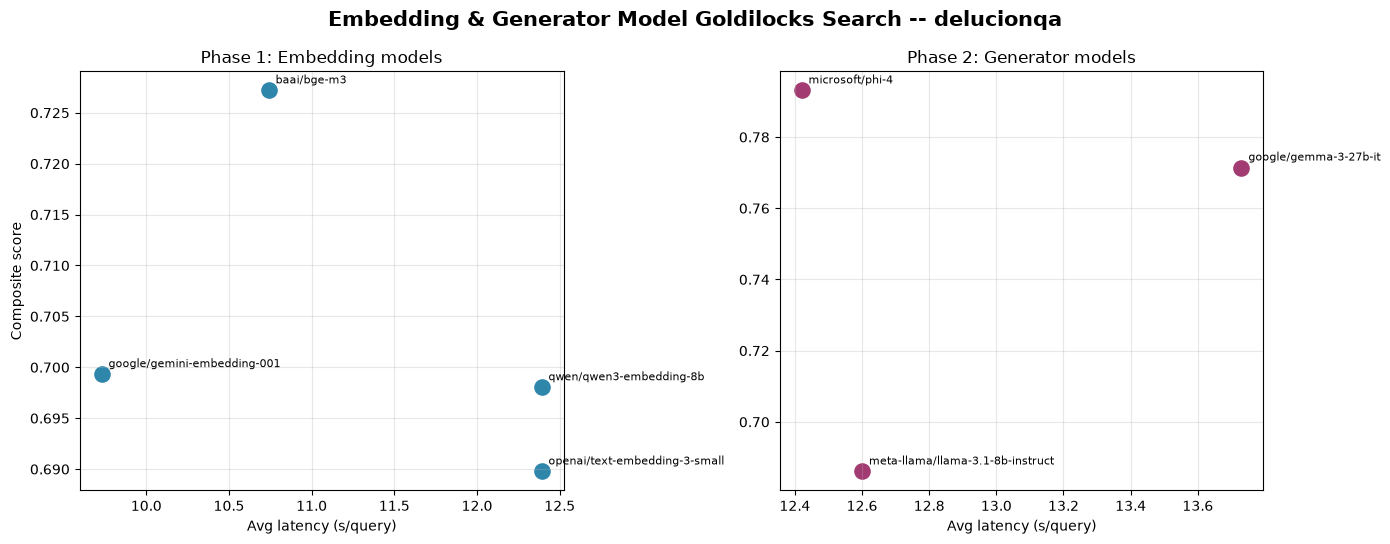

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f"Embedding & Generator Model Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"])
axes[0].scatter(p1_plot["avg_latency_sec"], p1_plot["composite"], s=120, color="#2E86AB")
for _, row in p1_plot.iterrows():
    axes[0].annotate(row["config"].replace("p1_", ""), (row["avg_latency_sec"], row["composite"]),
                      fontsize=8, xytext=(5, 5), textcoords="offset points")
axes[0].set_xlabel("Avg latency (s/query)")
axes[0].set_ylabel("Composite score")
axes[0].set_title("Phase 1: Embedding models")
axes[0].grid(True, alpha=0.3)

p2_plot = phase2_df.dropna(subset=["composite"])
axes[1].scatter(p2_plot["avg_latency_sec"], p2_plot["composite"], s=120, color="#A23B72")
for _, row in p2_plot.iterrows():
    axes[1].annotate(row["config"].replace("p2_", ""), (row["avg_latency_sec"], row["composite"]),
                      fontsize=8, xytext=(5, 5), textcoords="offset points")
axes[1].set_xlabel("Avg latency (s/query)")
axes[1].set_title("Phase 2: Generator models")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 10: Final Recommendation

In [10]:
all_results_df = pd.concat([phase1_df, phase2_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS BOTH PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "n_eval", "n_failed", "avg_latency_sec",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

phase2_winner = phase2_df.dropna(subset=["composite"]).iloc[0]
phase1_baseline = phase1_df[phase1_df["config"] == "p1_openai/text-embedding-3-small"].iloc[0]
phase2_baseline = phase2_df[phase2_df["config"] == f"p2_{DEFAULT_GENERATOR_MODEL}"].iloc[0]

print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS CONFIG: embedding={phase1_winner_model}, generator={phase2_winner['config'].replace('p2_', '')}")
print("=" * 100)
print(f"  Context Relevance:  {phase2_winner['context_relevance']:.4f}")
print(f"  Utilization:        {phase2_winner['utilization']:.4f}")
print(f"  Completeness:       {phase2_winner['completeness']:.4f}")
print(f"  Adherence:          {phase2_winner['adherence']:.4f}")
print(f"  Composite:          {phase2_winner['composite']:.4f}")
print(f"  Avg latency:        {phase2_winner['avg_latency_sec']:.2f}s/query")
print(f"  Eval sample:        {phase2_winner['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {phase2_winner['n_failed']})")

if phase1_baseline["composite"] is not None:
    emb_delta = phase1_winner_row["composite"] - phase1_baseline["composite"]
    print(f"\n  Embedding vs. original default (text-embedding-3-small): {emb_delta:+.4f} composite")
if phase2_baseline["composite"] is not None:
    gen_delta = phase2_winner["composite"] - phase2_baseline["composite"]
    print(f"  Generator vs. original default (llama-3.1-8b-instruct):  {gen_delta:+.4f} composite, "
          f"{phase2_winner['avg_latency_sec'] - phase2_baseline['avg_latency_sec']:+.2f}s latency")
print("=" * 100)


ALL CONFIGS ACROSS BOTH PHASES, RANKED BY COMPOSITE SCORE


,config,n_eval,n_failed,avg_latency_sec,context_relevance,utilization,completeness,adherence,composite
4,p2_microsoft/phi-4,20,0,12.42,0.717915,0.627780,0.884445,0.90,0.793104
5,p2_google/gemma-3-27b-it,20,0,13.73,0.653330,0.496535,0.788615,1.00,0.771438
0,p1_baai/bge-m3,20,0,10.74,0.605140,0.388615,0.714050,1.00,0.727199
1,p1_google/gemini-embedding-001,20,0,9.73,0.632220,0.402500,0.684525,0.90,0.699331
2,p1_qwen/qwen3-embedding-8b,20,0,12.39,0.618330,0.410835,0.700000,0.90,0.698041
3,p1_openai/text-embedding-3-small,20,0,12.39,0.568475,0.384175,0.671190,0.95,0.689771
6,p2_meta-llama/llama-3.1-8b-instruct,20,0,12.60,0.627360,0.369170,0.640835,0.90,0.686077



🏆 GOLDILOCKS CONFIG: embedding=baai/bge-m3, generator=microsoft/phi-4
  Context Relevance:  0.7179
  Utilization:        0.6278
  Completeness:       0.8844
  Adherence:          0.9000
  Composite:          0.7931
  Avg latency:        12.42s/query
  Eval sample:        20/20 succeeded (failed: 0)

  Embedding vs. original default (text-embedding-3-small): +0.0374 composite
  Generator vs. original default (llama-3.1-8b-instruct):  +0.1070 composite, -0.18s latency


### Caveats -- do not treat these exact numbers as final

- **Still a single run on one fixed 20-question sample.** `16` already showed this series'
  own noise floor is around 0.02-0.03 composite -- treat differences smaller than that as
  inconclusive.
- **Chunking, retrieval method/alpha, query transformation, reranker, and repacking held
  constant** at `11`-`15`'s winning configs. A different embedding model could plausibly
  shift which retrieval alpha or k is optimal -- not re-swept here.
- **HyDE's own generation model is held fixed** across both phases (this notebook's
  default), not tied to whichever generator wins Phase 2 -- isolates embedding/generator
  choice from `13`'s already-settled query-transformation question.
- **Latency numbers reflect this run's network conditions and OpenRouter routing**, not a
  controlled benchmark -- treat them as directional (which models are in the same ballpark
  vs. clearly slower), not precise SLA figures.
- **Some listed models may be renamed, deprecated, or rate-limited by the time this runs** --
  OpenRouter's catalog changes over time; a failed candidate is caught and reported as a
  zero-composite row rather than crashing the notebook, but should be re-verified against
  the live catalog if this is re-run much later.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`-`16` for comparability. A deployment optimizing for cost/latency over quality might
  reasonably pick a different generator than the composite-score winner here.
